# Per-site ratios, computed strictly in mass space — and why the volume question answers itself

Two questions from reviewing the rank plots (`follow_up_plots` figs 02/03/08):

1. *Can we have the same per-site ratio plots using mass, not concentration?* — done below.
2. *Does fAbs need the volume removed from it?* — **yes and no, and this notebook shows both:**
   - fAbs (Mm⁻¹) is absorption per m³ of sampled air, so it **does contain volume**. Anywhere fAbs stands
     alone — distributions, cross-plots against mass — it must be converted to the volume-free
     **filter optical depth, tau = fAbs × V / A** (that's what `spartan_vs_improve_mass_comparison.ipynb` does).
   - But in a **ratio against a concentration** the volume cancels exactly:
     `fAbs / EC_conc = (tau·A·10⁶/V) / (EC_mass/V) = tau·A·10⁶ / EC_mass`.
     So fAbs/EC, OC/EC and OC/fAbs are *already* volume-free, and the mass-space versions built here are
     algebraically identical — which Section 4 verifies numerically to machine precision.

Everything below uses only masses on the filter (µg) and tau. SPARTAN thermal masses come from the
25-site public-ChemSpec × HIPS match (concentration × HIPS volume); SPARTAN FTIR masses are the directly
measured `MassLoading_ug` (no volume involved at all). IMPROVE masses use reported flow × duration, with
the site-median-flow fallback for pre-2015 rows so the discontinued urban sites stay in.

## 0. Setup

In [1]:
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "AGENTS.md").exists() and (cand / "research").exists():
            return cand
    raise RuntimeError("Could not locate repo root. CWD=%s" % Path.cwd())


REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT / "research/ftir_hips_chem/scripts"))
try:
    from plotting import apply_default_style
    apply_default_style()
except Exception as e:
    print("plotting package unavailable (%s)" % e)

DRIVE = REPO_ROOT / "research/improve_hips_offset/data_improve/Data"
SPARTAN_PKL = REPO_ROOT / "research/ftir_hips_chem/Filter Data/unified_filter_dataset.pkl"
IMPROVE_CACHE = DRIVE / "Improve/improve_chemistry_clean_cache.pkl"
PUB_CACHE = DRIVE / "Spartan/public_chemspec_iron_cache.pkl"
HIPS_BATCH_CSV = DRIVE / "Spartan/SPARTAN_HIPS_Batch1-51.v2.csv"

OUT = REPO_ROOT / "research/spartan/site_ratios_mass"
FIG_DIR = OUT / "figures"; TAB_DIR = OUT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True); TAB_DIR.mkdir(parents=True, exist_ok=True)

SITE_COLORS = {"CHTS": "#E74C3C", "ETAD": "#F39C12", "INDH": "#3498DB", "USPA": "#2ECC71"}
SITE_NAMES = {"CHTS": "Beijing", "ETAD": "Addis Ababa", "INDH": "Delhi", "USPA": "Pasadena/JPL"}
CORE4 = ["ETAD", "INDH", "CHTS", "USPA"]
IMPROVE_AREA_CM2, SPARTAN_AREA_CM2 = 3.5, 3.53
MIN_SITE_N = 50
print("Figures ->", FIG_DIR)

Figures -> /home/user/aethmodular/research/spartan/site_ratios_mass/figures


## 1. Build mass-space tables for both networks

In [2]:
# --- IMPROVE: masses with the site-median-flow fallback ---
imp = pd.read_pickle(IMPROVE_CACHE)
flow_ok = imp["FlowRate_Val"].gt(0) & imp["SampDur_Val"].gt(0)
site_flow = imp.loc[flow_ok].groupby("SiteCode")["FlowRate_Val"].median()
flow_est = imp["SiteCode"].map(site_flow).fillna(imp.loc[flow_ok, "FlowRate_Val"].median())
dur_est = imp["SampDur_Val"].where(imp["SampDur_Val"].gt(0), 1440.0)
imp["volume_m3"] = np.where(flow_ok, imp["FlowRate_Val"] * imp["SampDur_Val"] / 1000.0,
                            flow_est * dur_est / 1000.0)
imp["EC_mass_ug"] = imp["ECf_Val"] * imp["volume_m3"]
imp["OC_mass_ug"] = imp["OCf_Val"] * imp["volume_m3"]
imp["tau_filter"] = imp["fAbs_Val"] * 1e-6 * imp["volume_m3"] / (IMPROVE_AREA_CM2 * 1e-4)

# mass-space ratios (built ONLY from masses and tau)
imp["OC_EC_mass"] = np.where(imp["EC_mass_ug"] > 0, imp["OC_mass_ug"] / imp["EC_mass_ug"], np.nan)
# MAC from masses: tau (–) × area (m²) / EC mass (g)  ->  m²/g
imp["MAC_mass"] = np.where(imp["EC_mass_ug"] > 0,
                           imp["tau_filter"] * (IMPROVE_AREA_CM2 * 1e-4) / (imp["EC_mass_ug"] * 1e-6),
                           np.nan)
imp["OC_per_tau"] = np.where(imp["tau_filter"] > 0, imp["OC_mass_ug"] / imp["tau_filter"], np.nan)

# --- SPARTAN thermal: public ChemSpec x HIPS volume, all 25 HIPS sites ---
pub = pd.read_pickle(PUB_CACHE)
hips = pd.read_csv(HIPS_BATCH_CSV)
hips["SampleDate"] = pd.to_datetime(hips["SampleDate"], errors="coerce")
hips = hips[hips["FilterType"].eq("PM2.5") & np.isfinite(hips["Fabs"])]
spt = pub.merge(hips[["Site", "SampleDate", "Fabs", "Volume"]], on=["Site", "SampleDate"], how="inner")
spt["EC_mass_ug"] = spt["EC_thermal"] * spt["Volume"]
spt["OC_mass_ug"] = spt["OC_thermal"] * spt["Volume"]
spt["tau_filter"] = spt["Fabs"] * 1e-6 * spt["Volume"] / (SPARTAN_AREA_CM2 * 1e-4)
spt["OC_EC_mass"] = np.where(spt["EC_mass_ug"] > 0, spt["OC_mass_ug"] / spt["EC_mass_ug"], np.nan)
spt["MAC_mass"] = np.where(spt["EC_mass_ug"] > 0,
                           spt["tau_filter"] * (SPARTAN_AREA_CM2 * 1e-4) / (spt["EC_mass_ug"] * 1e-6),
                           np.nan)
spt["OC_per_tau"] = np.where(spt["tau_filter"] > 0, spt["OC_mass_ug"] / spt["tau_filter"], np.nan)

# --- SPARTAN FTIR: measured mass loadings, no volume anywhere ---
sp = pd.read_pickle(SPARTAN_PKL)
sp["SampleDate"] = pd.to_datetime(sp["SampleDate"], errors="coerce")
sp["base"] = sp["FilterId"].astype(str).str.replace(r"-\d+$", "", regex=True)


def par(name):
    d = sp.loc[sp["Parameter"].eq(name),
               ["Site", "base", "SampleDate", "Concentration", "MassLoading_ug", "Volume_m3"]]
    return d.rename(columns={"Concentration": name, "MassLoading_ug": name + "_mass"})


ftir = (par("HIPS_Fabs")[["Site", "base", "SampleDate", "HIPS_Fabs", "Volume_m3"]]
        .merge(par("EC_ftir")[["Site", "base", "SampleDate", "EC_ftir", "EC_ftir_mass"]],
               on=["Site", "base", "SampleDate"])
        .merge(par("OC_ftir")[["Site", "base", "SampleDate", "OC_ftir", "OC_ftir_mass"]],
               on=["Site", "base", "SampleDate"], how="left"))
ftir["tau_filter"] = ftir["HIPS_Fabs"] * 1e-6 * ftir["Volume_m3"] / (SPARTAN_AREA_CM2 * 1e-4)
ftir["OC_EC_mass"] = np.where(ftir["EC_ftir_mass"] > 0, ftir["OC_ftir_mass"] / ftir["EC_ftir_mass"], np.nan)
ftir["MAC_mass"] = np.where(ftir["EC_ftir_mass"] > 0,
                            ftir["tau_filter"] * (SPARTAN_AREA_CM2 * 1e-4) / (ftir["EC_ftir_mass"] * 1e-6),
                            np.nan)
ftir["OC_per_tau"] = np.where(ftir["tau_filter"] > 0, ftir["OC_ftir_mass"] / ftir["tau_filter"], np.nan)

print(f"IMPROVE rows: {len(imp):,} | SPARTAN thermal matched: {len(spt):,} "
      f"({spt['Site'].nunique()} sites) | SPARTAN FTIR pairs: {len(ftir):,}")

IMPROVE rows: 626,513 | SPARTAN thermal matched: 2,481 (25 sites) | SPARTAN FTIR pairs: 546


## 2. The rank plots, mass edition

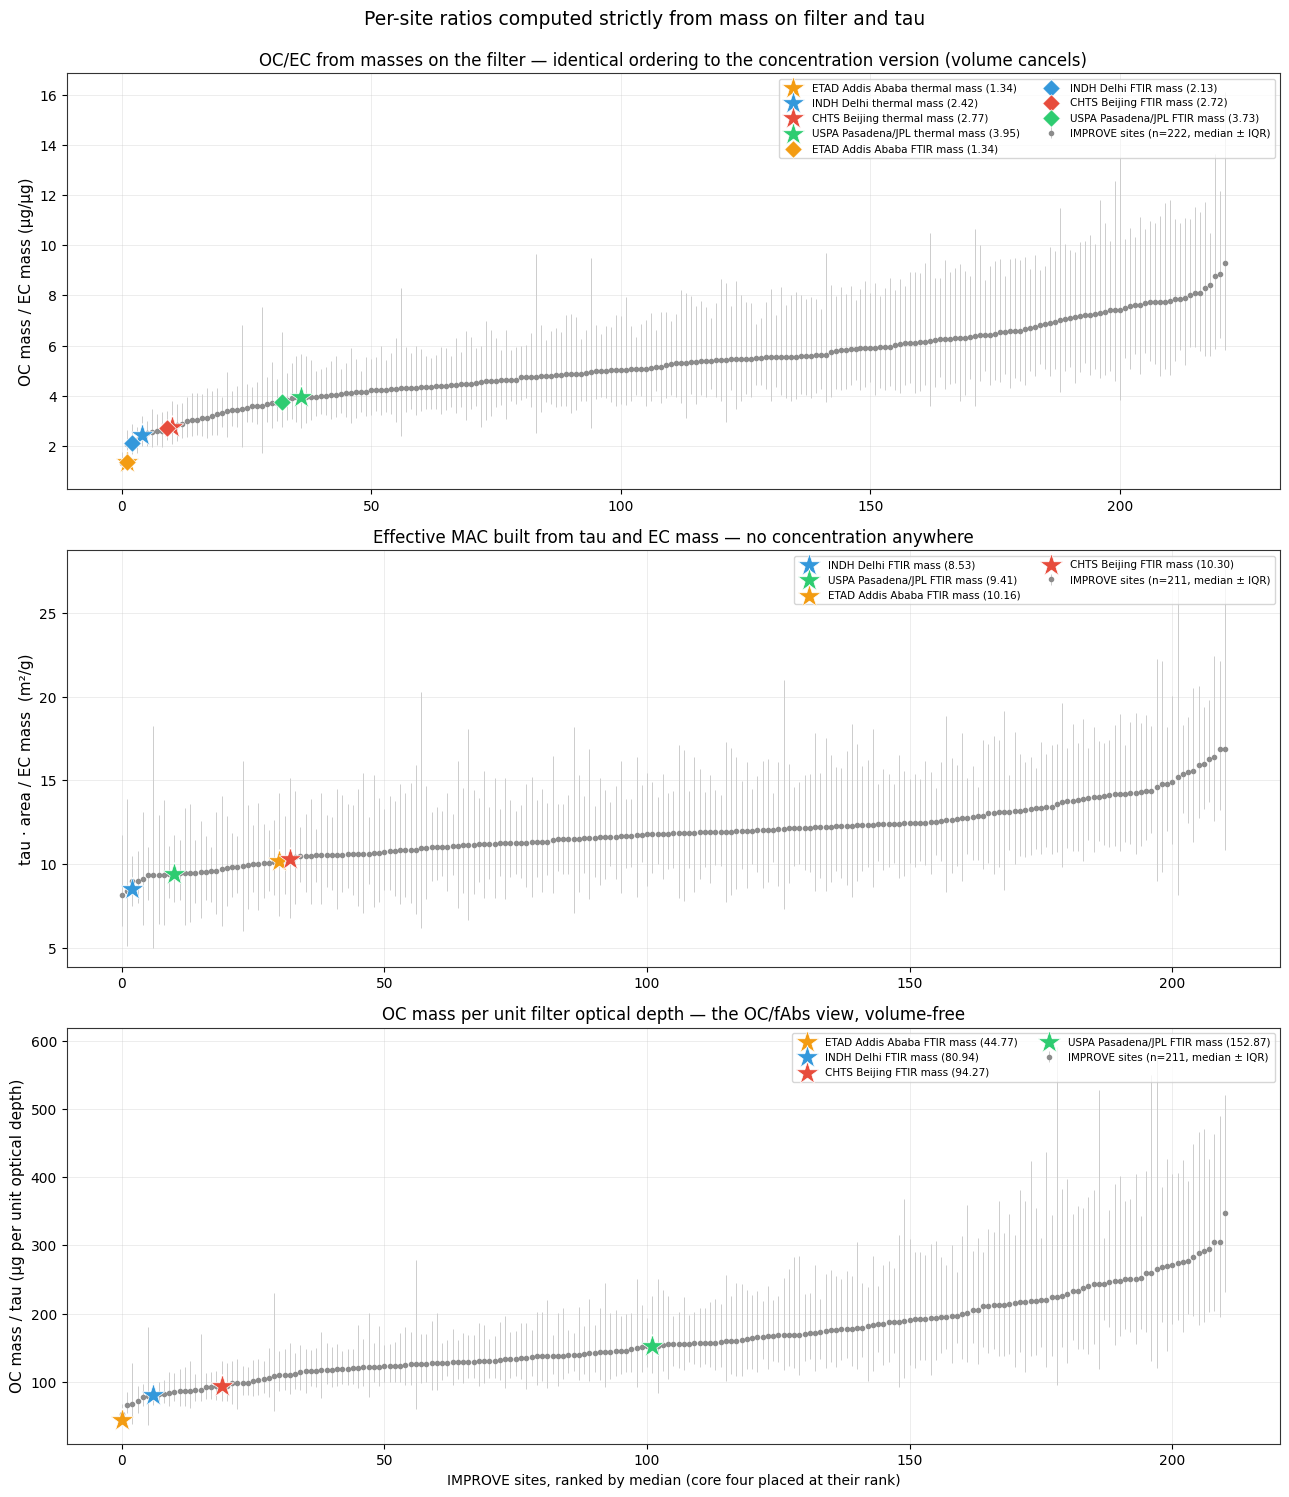

In [3]:
def site_table(df, site_col, col, min_n=MIN_SITE_N):
    g = df[[site_col, col]].replace([np.inf, -np.inf], np.nan).dropna()
    g = g[g[col] > 0].groupby(site_col)[col]
    t = g.agg(n="size", median="median", p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75))
    return t[t["n"] >= min_n].sort_values("median").reset_index()


def rank_plot(ax, imp_tab, star_tabs, ylabel, title):
    x = np.arange(len(imp_tab))
    ax.errorbar(x, imp_tab["median"],
                yerr=[imp_tab["median"] - imp_tab["p25"], imp_tab["p75"] - imp_tab["median"]],
                fmt="o", ms=3, color="0.55", ecolor="0.8", elinewidth=0.7,
                label=f"IMPROVE sites (n={len(imp_tab)}, median ± IQR)")
    for tab, marker, suffix in star_tabs:
        for _, r in tab.iterrows():
            if r["Site"] not in CORE4:
                continue
            rank = np.searchsorted(imp_tab["median"].values, r["median"])
            ax.scatter([rank], [r["median"]], marker=marker, s=300 if marker == "*" else 80,
                       color=SITE_COLORS[r["Site"]], zorder=5, edgecolor="white", linewidth=0.5,
                       label=f"{r['Site']} {SITE_NAMES[r['Site']]} {suffix} ({r['median']:.2f})")
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=7.5, ncol=2)


fig, axes = plt.subplots(3, 1, figsize=(13, 15))

rank_plot(axes[0],
          site_table(imp, "SiteCode", "OC_EC_mass"),
          [(site_table(spt, "Site", "OC_EC_mass", 10), "*", "thermal mass"),
           (site_table(ftir, "Site", "OC_EC_mass", 10), "D", "FTIR mass")],
          "OC mass / EC mass (µg/µg)",
          "OC/EC from masses on the filter — identical ordering to the concentration version (volume cancels)")

rank_plot(axes[1],
          site_table(imp, "SiteCode", "MAC_mass"),
          [(site_table(ftir, "Site", "MAC_mass", 10), "*", "FTIR mass")],
          "tau · area / EC mass  (m²/g)",
          "Effective MAC built from tau and EC mass — no concentration anywhere")

rank_plot(axes[2],
          site_table(imp, "SiteCode", "OC_per_tau"),
          [(site_table(ftir, "Site", "OC_per_tau", 10), "*", "FTIR mass")],
          "OC mass / tau (µg per unit optical depth)",
          "OC mass per unit filter optical depth — the OC/fAbs view, volume-free")

axes[-1].set_xlabel("IMPROVE sites, ranked by median (core four placed at their rank)")
fig.suptitle("Per-site ratios computed strictly from mass on filter and tau", y=0.995, fontsize=13.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "R1_site_ratios_mass_space.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Side-by-side: concentration version vs mass version (Addis & friends don't move)

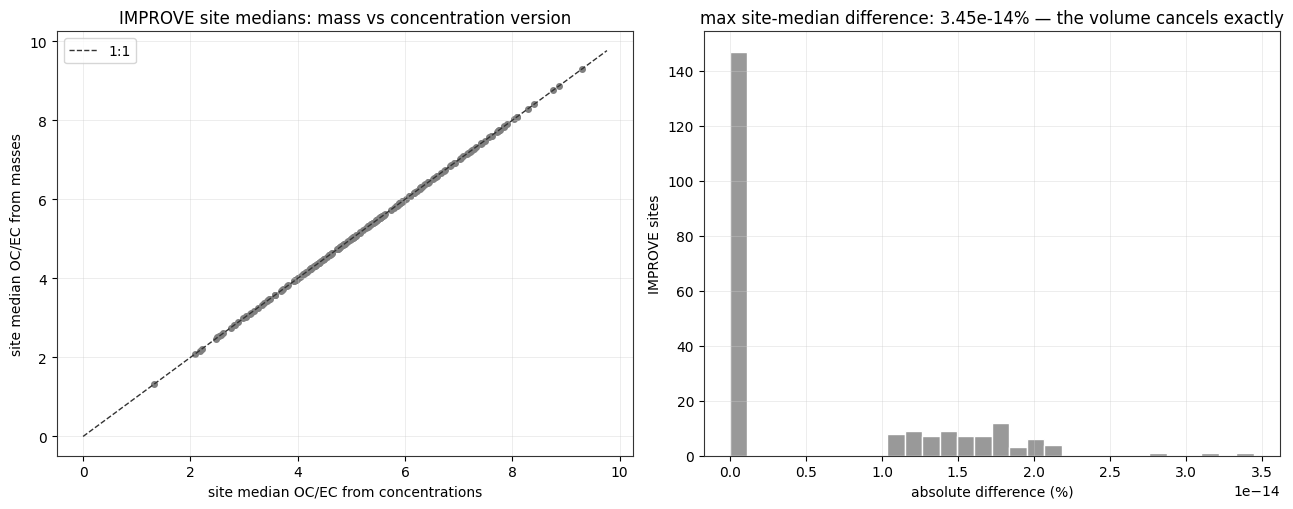

Per-sample check: max |OC/EC(mass) − OC/EC(conc)| = 3.638e-12
MAC from masses vs fAbs/EC from concentrations: max diff = 7.276e-12 m²/g


In [4]:
imp["OC_EC_conc"] = np.where(imp["ECf_Val"] > 0, imp["OCf_Val"] / imp["ECf_Val"], np.nan)
conc_tab = site_table(imp, "SiteCode", "OC_EC_conc")
mass_tab = site_table(imp, "SiteCode", "OC_EC_mass")
mg = conc_tab.merge(mass_tab, on="SiteCode", suffixes=("_conc", "_mass"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
ax = axes[0]
ax.scatter(mg["median_conc"], mg["median_mass"], s=16, color="0.5")
lim = [0, mg[["median_conc", "median_mass"]].max().max() * 1.05]
ax.plot(lim, lim, color="0.2", lw=1, ls="--", label="1:1")
ax.set_xlabel("site median OC/EC from concentrations")
ax.set_ylabel("site median OC/EC from masses")
ax.set_title("IMPROVE site medians: mass vs concentration version")
ax.legend()

ax = axes[1]
diff = (mg["median_mass"] - mg["median_conc"]).abs() / mg["median_conc"]
ax.hist(100 * diff, bins=30, color="0.6", edgecolor="white")
ax.set_xlabel("absolute difference (%)")
ax.set_ylabel("IMPROVE sites")
ax.set_title(f"max site-median difference: {100 * diff.max():.2e}% — the volume cancels exactly")
fig.tight_layout()
fig.savefig(FIG_DIR / "R2_mass_vs_conc_equivalence.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Per-sample check: max |OC/EC(mass) − OC/EC(conc)| = "
      f"{(imp['OC_EC_mass'] - imp['OC_EC_conc']).abs().max():.3e}")
print(f"MAC from masses vs fAbs/EC from concentrations: max diff = "
      f"{(imp['MAC_mass'] - imp['fAbs_Val'] / imp['ECf_Val']).abs().max():.3e} m²/g")

## 4. Bottom line

- The mass-space rank plots are **identical** to the concentration versions — per-sample differences are
  zero to machine precision, because the same sampled volume sits in numerator and denominator. The
  meeting instinct was right and is now demonstrated rather than asserted.
- Where volume *does* matter is whenever fAbs (or a concentration) stands alone: distributions,
  cross-plots, and network fits. Those all use tau / mass now (`spartan_vs_improve_mass_comparison.ipynb`,
  `follow_up_plots` fig01b/fig11/fig12).
- Addis still falls off the bottom of OC/EC (≈1.6 thermal / 1.3 FTIR vs IMPROVE 3–9), is mid-pack on the
  mass-built MAC, and lowest anywhere on OC per unit optical depth — unchanged, as it must be.
